In [1]:
import pandas as pd
df=pd.read_csv("../data/train.csv")

In [2]:
df.shape

(1460, 81)

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

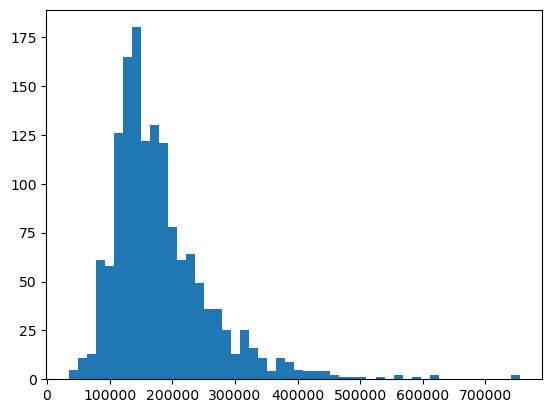

In [6]:
import matplotlib.pyplot as plt 

plt.hist(df["SalePrice"], bins=50)
plt.show()

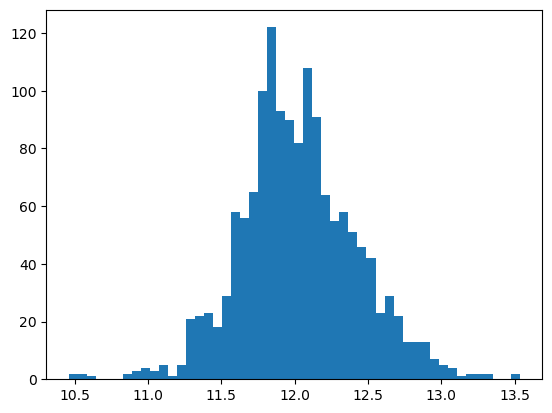

In [7]:
import numpy as np

plt.hist(np.log(df["SalePrice"]), bins=50)
plt.show()

In [8]:
X=df.drop("SalePrice", axis=1)
y=np.log(df["SalePrice"])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

PoolQC         1162
MiscFeature    1122
Alley          1094
Fence           935
MasVnrType      683
FireplaceQu     547
LotFrontage     217
GarageCond       64
GarageType       64
GarageYrBlt      64
dtype: int64

In [11]:
X_train.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [12]:
cols_fill_none=["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

for col in cols_fill_none:
    X_train[col]=X_train[col].fillna("None")
    X_test[col]=X_test[col].fillna("None")

In [13]:
numeric_cols=X_train.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    median=X_train[col].median()
    X_train[col]=X_train[col].fillna(median)
    X_test[col]=X_test[col].fillna(median)

In [14]:
X_train.isnull().sum().sum()

1080

In [15]:
cat_cols=X_train.select_dtypes(include="object").columns

for col in cat_cols:
    X_train[col]=X_train[col].fillna("None")
    X_test[col]=X_test[col].fillna("None")

In [16]:
X_train.isnull().sum().sum()

0

In [17]:
X_train=pd.get_dummies(X_train, drop_first=True)
X_test=pd.get_dummies(X_test, drop_first=True)

In [18]:
X_train, X_test=X_train.align(X_test, join='left', axis=1, fill_value=0)

In [19]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train, y_train)

y_pred=model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np 

mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(1.8464919853567638, 1.8686318383963025)

In [21]:
X_train.shape

(1168, 259)

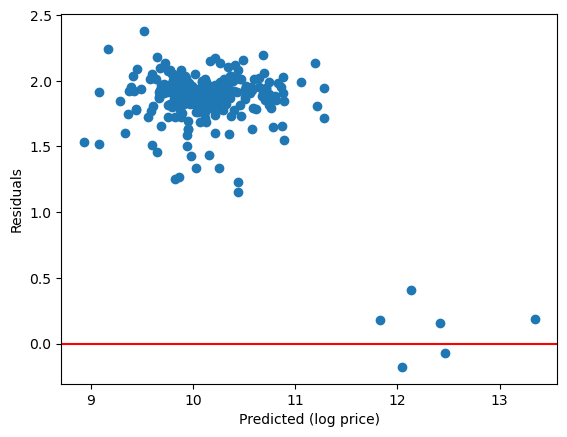

In [22]:
residuals=y_test-y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted (log price)")
plt.ylabel("Residuals")
plt.show()

In [23]:
residuals.min(), residuals.max(), residuals.mean()

(-0.1779583214769591, 2.3794708064800485, 1.8447780655717447)

In [24]:
from sklearn.linear_model import Ridge

ridge=Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge=ridge.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_ridge=mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge=np.sqrt(mean_squared_error(y_test, y_pred_ridge))

mae_ridge, rmse_ridge

(0.2808024146058638, 0.30191708014061996)

In [26]:
from sklearn.linear_model import Lasso

lasso=Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred_lasso=lasso.predict(X_test)

In [27]:
mae_lasso=mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso=np.sqrt(mean_squared_error(y_test, y_pred_lasso))

mae_lasso, rmse_lasso

(0.09940067157476858, 0.14336250702083506)

In [28]:
sum(lasso.coef_==0)

172

In [29]:
df=pd.read_csv("../data/train.csv")
X=df.drop("SalePrice", axis=1)
y=np.log(df["SalePrice"])

In [30]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
numeric_cols=X.select_dtypes(include=['int64','float64']).columns
categorical_cols=X.select_dtypes(include=['object']).columns

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

In [33]:
numeric_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [34]:
categorical_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [35]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [36]:
model=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'regressor__alpha':[0.01, 0.1, 1, 10, 50, 100]
}

grid=GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

grid.fit(X_train, y_train)

,estimator,"Pipeline(step...r', Ridge())])"
,param_grid,"{'regressor__alpha': [0.01, 0.1, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [38]:
best_model=grid.best_estimator_
y_pred=best_model.predict(X_test)

In [39]:
mae= mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(0.09692912505494493, 0.1389689701316915)

In [40]:
np.exp(rmse)

1.1490884433873247